# Async ML Data Construction Showcase

## Revenue Forecasting From Multi-Source Data (Synthetic E-commerce Example)

### Learning objectives
- Build a realistic ML-ready dataset from **master data + event logs**.
- Construct a target label from business logic: **future 90-day revenue**.
- Engineer behavioral features from historical transactions.
- Encode categorical variables with **one-hot encoding**.
- Prevent temporal leakage via strict **observation vs prediction windows**.

### Business framing
For each customer at reference date **t**, predict revenue in the next **90 days**. This mirrors production ML settings where we only have historical data at prediction time, while labels come from future outcomes.

In [1]:
import numpy as np
import pandas as pd
from datetime import timedelta

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [2]:
# Set the random seed for reproducibility 
SEED = 42
# Create a random number generator with the specified seed  
rng = np.random.default_rng(SEED)
np.random.seed(SEED)
print(f"Random seed set to {SEED}")

Random seed set to 42


## SECTION B — Generate Synthetic Raw Data

### SECTION B.1 — Generate Synthetic Customer Master Table

In [3]:
# Synthetic customer master table
n_customers = 1200

# Define the range of customer IDs 
customer_ids = [f"C{i:04d}" for i in range(1, n_customers + 1)]

# Define the values for the categorical features 
countries = ["DE", "FR", "CH", "IT", "ES"]
segments = ["Budget", "Standard", "Premium"]
channels = ["Organic", "Paid Ads", "Referral", "Affiliate"]

# Use a fixed synthetic timeline so notebook behavior is deterministic
synthetic_today = pd.Timestamp("2025-01-31")
signup_start = synthetic_today - pd.Timedelta(days=730)  # last 24 months
# Generate random signup dates for each customer  
signup_offsets = rng.integers(0, 731, size=n_customers)
signup_dates = signup_start + pd.to_timedelta(signup_offsets, unit="D")

# Create a DataFrame with the generated data 
customers = pd.DataFrame(
    {
        "customer_id": customer_ids,
        "signup_date": pd.to_datetime(signup_dates),
        "country": rng.choice(countries, size=n_customers, p=[0.25, 0.2, 0.15, 0.2, 0.2]),
        "customer_segment": rng.choice(segments, size=n_customers, p=[0.4, 0.45, 0.15]),
        "acquisition_channel": rng.choice(channels, size=n_customers, p=[0.35, 0.3, 0.2, 0.15]),
    }
)

customers.head()

,customer_id,signup_date,country,customer_segment,acquisition_channel
0,C0001,2023-04-07,CH,Standard,Referral
1,C0002,2024-08-19,IT,Standard,Paid Ads
2,C0003,2024-05-24,ES,Budget,Organic
3,C0004,2023-12-18,IT,Standard,Referral
4,C0005,2023-12-14,ES,Standard,Organic


### Section B.2. Generate synthetic transaction event table

In [4]:
# Synthetic transaction event table
# Design choices as underlying assumptions & distributional choices:
# - Premium customers spend more
# - Paid Ads customers tend to churn more / have fewer repeat purchases
# - Some customers have no transactions
# - Mild recency + seasonality effects

transaction_rows = []

# Define the range of transaction dates 
tx_global_start = synthetic_today - pd.Timedelta(days=420)  # >12 months history
tx_global_end = synthetic_today + pd.Timedelta(days=120)    # includes future wrt reference date

# Define the multipliers for the segment frequency and amount  
segment_freq_mult = {"Budget": 0.8, "Standard": 1.0, "Premium": 1.35}
segment_amount_mult = {"Budget": 0.75, "Standard": 1.0, "Premium": 1.8}
channel_freq_mult = {"Organic": 1.1, "Paid Ads": 0.75, "Referral": 1.05, "Affiliate": 0.9}
channel_no_tx_bonus = {"Organic": 0.00, "Paid Ads": 0.12, "Referral": 0.00, "Affiliate": 0.03}

# Iterate over each customer in the customers DataFrame 
for row in customers.itertuples(index=False):
    cid = row.customer_id
    signup = row.signup_date
    seg = row.customer_segment
    ch = row.acquisition_channel

    # Customers with short tenure have fewer possible transactions
    tenure_days = max((synthetic_today - signup).days, 1)
    tenure_factor = min(tenure_days / 365.0, 1.4)

    # Calculate the base lambda for the Poisson distribution 
    base_lambda = 4.5 * segment_freq_mult[seg] * channel_freq_mult[ch] * tenure_factor

    # Probability of no transactions at all
    p_no_tx = 0.08 + channel_no_tx_bonus[ch]
    if rng.random() < p_no_tx:
        continue

    # Generate the number of transactions for the customer following a Poisson distribution with the base lambda 
    n_tx = rng.poisson(base_lambda)
    if n_tx <= 0:
        n_tx = 1

    # Mild recency effect: some users get extra recent transactions
    if rng.random() < 0.25:
        n_tx += rng.integers(1, 4)

    # Define the range of transaction dates 
    tx_start = max(tx_global_start, signup)
    tx_end = tx_global_end
    n_days = max((tx_end - tx_start).days, 1)

    # Build date weights: slightly more recent + mild seasonal bump in Nov/Dec
    date_index = pd.date_range(tx_start, tx_end, freq="D")
    recency_weight = np.linspace(0.8, 1.2, len(date_index))
    seasonal_weight = np.where(date_index.month.isin([11, 12]), 1.15, 1.0)
    day_weights = recency_weight * seasonal_weight
    day_weights = day_weights / day_weights.sum()

    # Choose the transaction dates for the customer from the date_index array 
    chosen_dates = rng.choice(date_index, size=n_tx, replace=True, p=day_weights)

    # Iterate over the chosen transaction dates  
    for tx_date in chosen_dates:
        # Log-normal amount with segment effect + occasional outliers
        amount = rng.lognormal(mean=3.6, sigma=0.55) * segment_amount_mult[seg]

        # Occasionally generate outlier purchases 
        if rng.random() < 0.015:
            amount *= rng.uniform(5, 12)  # outlier purchases

        # Small seasonal uplift around Nov/Dec
        if pd.Timestamp(tx_date).month in [11, 12]:
            amount *= 1.08

        # Append the transaction data to the transaction_rows list  
        transaction_rows.append(
            {
                "customer_id": cid,
                "transaction_date": pd.Timestamp(tx_date),
                "amount": float(round(amount, 2)),
            }
        )

# Convert the transaction_rows list into a DataFrame 
transactions = pd.DataFrame(transaction_rows)   
# Sort the transactions by customer ID and transaction date 
transactions = transactions.sort_values(["customer_id", "transaction_date"]).reset_index(drop=True)
# Display the first few rows of the transactions DataFrame 
transactions.head()

,customer_id,transaction_date,amount
0,C0001,2024-02-18,30.96
1,C0001,2024-04-14,24.45
2,C0001,2024-07-15,44.53
3,C0001,2024-09-05,34.86
4,C0001,2024-11-07,23.09


In [5]:
# Basic sanity checks
print("Customers head:")
display(customers.head())

# Display the first few rows of the transactions DataFrame  
print("\nTransactions head:")
display(transactions.head())

# Print the row counts for the customers and transactions DataFrames  
print("\nRow counts")
print("customers:", len(customers))
print("transactions:", len(transactions))

# Print the number of unique customers in the customers and transactions DataFrames   
print("\nUnique customers")
print("customers table:", customers["customer_id"].nunique())
print("transactions table:", transactions["customer_id"].nunique())

# Calculate the number of customers with no transactions 
customers_with_no_tx = customers.loc[~customers["customer_id"].isin(transactions["customer_id"]), "customer_id"].nunique()
print("customers with no transactions:", customers_with_no_tx)

# Print the number of missing values in the customers and transactions DataFrames   
print("\nMissing values")
print("customers:\n", customers.isna().sum())
print("transactions:\n", transactions.isna().sum())

Customers head:


,customer_id,signup_date,country,customer_segment,acquisition_channel
0,C0001,2023-04-07,CH,Standard,Referral
1,C0002,2024-08-19,IT,Standard,Paid Ads
2,C0003,2024-05-24,ES,Budget,Organic
3,C0004,2023-12-18,IT,Standard,Referral
4,C0005,2023-12-14,ES,Standard,Organic



Transactions head:


,customer_id,transaction_date,amount
0,C0001,2024-02-18,30.96
1,C0001,2024-04-14,24.45
2,C0001,2024-07-15,44.53
3,C0001,2024-09-05,34.86
4,C0001,2024-11-07,23.09



Row counts
customers: 1200
transactions: 4636

Unique customers
customers table: 1200
transactions table: 1046
customers with no transactions: 154

Missing values
customers:
 customer_id            0
signup_date            0
country                0
customer_segment       0
acquisition_channel    0
dtype: int64
transactions:
 customer_id         0
transaction_date    0
amount              0
dtype: int64


In [6]:
# Save the synthetic data to a CSV file
customers.to_csv("../data/customers.csv", index=False)
transactions.to_csv("../data/transactions.csv", index=False)


print("Synthetic data saved to CSV files")



Synthetic data saved to CSV files


## SECTION C — Define Temporal Windows and Reference Date

Now, we have (synthesized) our raw data set. Often this is the starting point of data that you get from your business stakeholders. 

Next, we must separate:
- **Observation window**: historical data used to build features.
- **Prediction window**: future period used to construct the label.

If we accidentally include prediction-window information in features, we create **temporal leakage**.

In [7]:
# Reference date and windows
# Choose t so we still have enough future transactions to build labels
reference_date = transactions["transaction_date"].max() - pd.Timedelta(days=120)

# Define the observation and prediction windows in days, as discussed in the slides  
observation_days = 180
prediction_days = 90

# Calculate the start and end dates for the observation and prediction windows   
obs_start = reference_date - pd.Timedelta(days=observation_days)
obs_end = reference_date

# Calculate the start and end dates for the prediction window   
pred_start = reference_date
pred_end = reference_date + pd.Timedelta(days=prediction_days)

# Print the reference date and the observation and prediction windows  
print("reference_date (t):", reference_date.date())
print(f"observation window: [{obs_start.date()}, {obs_end.date()}]")
print(f"prediction window: ({pred_start.date()}, {pred_end.date()}]")

reference_date (t): 2025-01-31
observation window: [2024-08-04, 2025-01-31]
prediction window: (2025-01-31, 2025-05-01]


## SECTION D — Label Construction (Future Revenue)

Define target for customer *i* as:

\[
y_i = \sum \text{amount}_{i, d} \text{ for } d \in (t, t+90]
\]

Customers with no transactions in the prediction window get label **0**.

In [8]:
# Prediction-window transactions: (t, t+90]
pred_tx = transactions[
    (transactions["transaction_date"] > pred_start)
    & (transactions["transaction_date"] <= pred_end)
].copy()

# Group the transactions by customer ID and sum the amount for each customer  
label_df = (
    pred_tx.groupby("customer_id", as_index=False)["amount"]
    .sum()
    .rename(columns={"amount": "future_revenue_90d"})
)

# Ensure every customer exists in label table
label_df = customers[["customer_id"]].merge(label_df, on="customer_id", how="left")
label_df["future_revenue_90d"] = label_df["future_revenue_90d"].fillna(0.0)

# Print a summary of the label distribution 
print("Label summary:")
print(label_df["future_revenue_90d"].describe())

# Calculate the percentage of zero labels  
pct_zero = (label_df["future_revenue_90d"] == 0).mean() * 100
print(f"Percent zero labels: {pct_zero:.2f}%")

Label summary:
count    1200.000000
mean       46.428433
std        80.516101
min         0.000000
25%         0.000000
50%        19.955000
75%        62.417500
max      1070.010000
Name: future_revenue_90d, dtype: float64
Percent zero labels: 45.17%


## SECTION E — Feature Engineering From Observation Window (Past Behavior)

We engineer RFM-style and trend features only from historical data in **[t-180, t]**.

No transaction after **t** is used for features (prevents leakage).

### SECTION E.1: Define the range of the past 180 days

In [9]:
# Observation-window transactions: [t-180, t], i.e. 180 days before t 
obs_tx = transactions[
    (transactions["transaction_date"] >= obs_start)
    & (transactions["transaction_date"] <= obs_end)
].copy()
obs_tx["tx_day"] = obs_tx["transaction_date"].dt.normalize()

obs_tx.head() 

,customer_id,transaction_date,amount,tx_day
3,C0001,2024-09-05,34.86,2024-09-05
4,C0001,2024-11-07,23.09,2024-11-07
5,C0001,2025-01-06,54.76,2025-01-06
13,C0004,2024-09-20,27.63,2024-09-20
14,C0004,2024-10-24,20.84,2024-10-24


### SECTION E.2. Core Behavior Features

In [10]:
# Core behavior features in observation window
# Group by customer ID and calculate the following metrics:
# - last_purchase_date: the latest transaction date for each customer
# - frequency: the number of transactions for each customer
# - monetary_total: the total amount spent by each customer
# - active_days: the number of unique days on which each customer has made a purchase 
obs_agg = obs_tx.groupby("customer_id").agg(
    last_purchase_date=("transaction_date", "max"),
    frequency=("amount", "count"),
    monetary_total=("amount", "sum"),
    active_days=("tx_day", "nunique"),
)
# Calculate the average order value for each customer 
obs_agg["avg_order_value"] = obs_agg["monetary_total"] / obs_agg["frequency"]
obs_agg = obs_agg.reset_index()

# Recency (days since last purchase)
obs_agg["recency_days"] = (reference_date - obs_agg["last_purchase_date"]).dt.days

obs_agg.head()

,customer_id,last_purchase_date,frequency,monetary_total,active_days,avg_order_value,recency_days
0,C0001,2025-01-06,3,112.71,3,37.570,25
1,C0004,2024-10-24,2,48.47,2,24.235,99
2,C0005,2024-12-01,1,49.24,1,49.240,61
3,C0008,2024-12-16,2,80.94,2,40.470,46
4,C0009,2024-12-01,2,171.99,2,85.995,61


### SECTION E.3. Trend features


In [11]:
# Calculate the sum of the amount for each customer in the recent 30 days  
recent_30d = obs_tx[
    (obs_tx["transaction_date"] > (reference_date - pd.Timedelta(days=30)))
    & (obs_tx["transaction_date"] <= reference_date)
]

# Calculate the sum of the amount for each customer in the previous 30 days 
prev_30d = obs_tx[
    (obs_tx["transaction_date"] > (reference_date - pd.Timedelta(days=60)))
    & (obs_tx["transaction_date"] <= (reference_date - pd.Timedelta(days=30)))
]

# Calculate the sum of the amount for each customer in the recent 30 days 
recent_30d_spend = (
    recent_30d.groupby("customer_id", as_index=False)["amount"]
    .sum()
    .rename(columns={"amount": "recent_30d_spend"})
)

# Calculate the sum of the amount for each customer in the previous 30 days  
prev_30d_spend = (
    prev_30d.groupby("customer_id", as_index=False)["amount"]
    .sum()
    .rename(columns={"amount": "prev_30d_spend"})
)

# Merge the recent 30 days spend and previous 30 days spend into the observation aggregate DataFrame 
features_df = obs_agg.merge(recent_30d_spend, on="customer_id", how="left")
features_df = features_df.merge(prev_30d_spend, on="customer_id", how="left")
features_df[["recent_30d_spend", "prev_30d_spend"]] = features_df[["recent_30d_spend", "prev_30d_spend"]].fillna(0.0)
features_df["spend_trend"] = features_df["recent_30d_spend"] - features_df["prev_30d_spend"]

features_df.head()

,customer_id,last_purchase_date,frequency,monetary_total,active_days,avg_order_value,recency_days,recent_30d_spend,prev_30d_spend,spend_trend
0,C0001,2025-01-06,3,112.71,3,37.570,25,54.76,0.00,54.76
1,C0004,2024-10-24,2,48.47,2,24.235,99,0.00,0.00,0.00
2,C0005,2024-12-01,1,49.24,1,49.240,61,0.00,0.00,0.00
3,C0008,2024-12-16,2,80.94,2,40.470,46,0.00,34.31,-34.31
4,C0009,2024-12-01,2,171.99,2,85.995,61,0.00,0.00,0.00


### Data Cleansing!!

**Missing-value handling choices:**
- Customers with no observation-window transactions get `frequency=0`, `monetary_total=0`, `active_days=0`, `recent_30d_spend=0`, `prev_30d_spend=0`, `spend_trend=0`.
- `avg_order_value` is set to 0 when `frequency=0`.
- `recency_days` is set to a large value (`observation_days + 1`) for "not recently active" customers.

In [12]:
# Merge engineered features into customer table
model_base = customers.merge(features_df, on="customer_id", how="left")

# Fill missing values with 0.0 for the following columns 
fill_zero_cols = [
    "frequency",
    "monetary_total",
    "active_days",
    "recent_30d_spend",
    "prev_30d_spend",
    "spend_trend",
]

# Fill missing values with 0.0 for the following columns  
for col in fill_zero_cols:
    model_base[col] = model_base[col].fillna(0.0)

# Fill missing values with a large value for the following columns  
model_base["recency_days"] = model_base["recency_days"].fillna(observation_days + 1)
model_base["avg_order_value"] = model_base["avg_order_value"].fillna(0.0)

# last_purchase_date is not used as model feature directly
model_base = model_base.drop(columns=["last_purchase_date"], errors="ignore")

model_base.head()

,customer_id,signup_date,country,customer_segment,acquisition_channel,frequency,monetary_total,active_days,avg_order_value,recency_days,recent_30d_spend,prev_30d_spend,spend_trend
0,C0001,2023-04-07,CH,Standard,Referral,3.0,112.71,3.0,37.570,25.0,54.76,0.0,54.76
1,C0002,2024-08-19,IT,Standard,Paid Ads,0.0,0.00,0.0,0.000,181.0,0.00,0.0,0.00
2,C0003,2024-05-24,ES,Budget,Organic,0.0,0.00,0.0,0.000,181.0,0.00,0.0,0.00
3,C0004,2023-12-18,IT,Standard,Referral,2.0,48.47,2.0,24.235,99.0,0.00,0.0,0.00
4,C0005,2023-12-14,ES,Standard,Organic,1.0,49.24,1.0,49.240,61.0,0.00,0.0,0.00


## SECTION F — Add Tenure Feature

In [13]:
model_base["tenure_days"] = (reference_date - model_base["signup_date"]).dt.days
model_base[["customer_id", "signup_date", "tenure_days"]].head()

model_base.head()

,customer_id,signup_date,country,customer_segment,acquisition_channel,frequency,monetary_total,active_days,avg_order_value,recency_days,recent_30d_spend,prev_30d_spend,spend_trend,tenure_days
0,C0001,2023-04-07,CH,Standard,Referral,3.0,112.71,3.0,37.570,25.0,54.76,0.0,54.76,665
1,C0002,2024-08-19,IT,Standard,Paid Ads,0.0,0.00,0.0,0.000,181.0,0.00,0.0,0.00,165
2,C0003,2024-05-24,ES,Budget,Organic,0.0,0.00,0.0,0.000,181.0,0.00,0.0,0.00,252
3,C0004,2023-12-18,IT,Standard,Referral,2.0,48.47,2.0,24.235,99.0,0.00,0.0,0.00,410
4,C0005,2023-12-14,ES,Standard,Organic,1.0,49.24,1.0,49.240,61.0,0.00,0.0,0.00,414


## SECTION G — Handle Categorical Features (One-Hot Encoding)

Categorical fields (`country`, `customer_segment`, `acquisition_channel`) cannot be used directly by most ML models. We one-hot encode them into binary indicator columns.

We avoid arbitrary ordinal encoding here because there is no meaningful numeric order between categories.

In [14]:
# Identify the column types so far 
model_base.dtypes

customer_id                       str
signup_date            datetime64[us]
country                           str
customer_segment                  str
acquisition_channel               str
frequency                     float64
monetary_total                float64
active_days                   float64
avg_order_value               float64
recency_days                  float64
recent_30d_spend              float64
prev_30d_spend                float64
spend_trend                   float64
tenure_days                     int64
dtype: object

In [15]:
# Select the categorical columns dedicatedly  
categorical_cols = ["country", "customer_segment", "acquisition_channel"]
numeric_cols = [
    "recency_days",
    "frequency",
    "monetary_total",
    "avg_order_value",
    "active_days",
    "recent_30d_spend",
    "prev_30d_spend",
    "spend_trend",
    "tenure_days",
]

# Keep a clean feature frame (exclude identifiers/date columns)
feature_input = model_base[["customer_id", "signup_date"] + categorical_cols + numeric_cols].copy()

feature_input.head()

,customer_id,signup_date,country,customer_segment,acquisition_channel,recency_days,frequency,monetary_total,avg_order_value,active_days,recent_30d_spend,prev_30d_spend,spend_trend,tenure_days
0,C0001,2023-04-07,CH,Standard,Referral,25.0,3.0,112.71,37.570,3.0,54.76,0.0,54.76,665
1,C0002,2024-08-19,IT,Standard,Paid Ads,181.0,0.0,0.00,0.000,0.0,0.00,0.0,0.00,165
2,C0003,2024-05-24,ES,Budget,Organic,181.0,0.0,0.00,0.000,0.0,0.00,0.0,0.00,252
3,C0004,2023-12-18,IT,Standard,Referral,99.0,2.0,48.47,24.235,2.0,0.00,0.0,0.00,410
4,C0005,2023-12-14,ES,Standard,Organic,61.0,1.0,49.24,49.240,1.0,0.00,0.0,0.00,414


In [16]:
# One-hot encode the categorical columns  
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

# Fit the preprocessor on the feature input  
X_array = preprocessor.fit_transform(feature_input[categorical_cols + numeric_cols])

# Get the feature names from the preprocessor   
cat_feature_names = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_cols).tolist()
final_feature_names = cat_feature_names + numeric_cols

# Create a DataFrame with the one-hot encoded features   
X = pd.DataFrame(X_array, columns=final_feature_names, index=feature_input.index)

# Print the number of one-hot columns created and the total number of feature columns in X    
print("One-hot columns created:", len(cat_feature_names))
print("Total feature columns in X:", X.shape[1])
X.head()

One-hot columns created: 12
Total feature columns in X: 21


,country_CH,country_DE,country_ES,country_FR,country_IT,customer_segment_Budget,customer_segment_Premium,customer_segment_Standard,acquisition_channel_Affiliate,acquisition_channel_Organic,...,acquisition_channel_Referral,recency_days,frequency,monetary_total,avg_order_value,active_days,recent_30d_spend,prev_30d_spend,spend_trend,tenure_days
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,25.0,3.0,112.71,37.570,3.0,54.76,0.0,54.76,665.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,181.0,0.0,0.00,0.000,0.0,0.00,0.0,0.00,165.0
2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,181.0,0.0,0.00,0.000,0.0,0.00,0.0,0.00,252.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,99.0,2.0,48.47,24.235,2.0,0.00,0.0,0.00,410.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,61.0,1.0,49.24,49.240,1.0,0.00,0.0,0.00,414.0


## SECTION H — Final Dataset Assembly

In [17]:
# Join target y
final_dataset = pd.concat(
    [
        model_base[["customer_id"]].reset_index(drop=True),
        X.reset_index(drop=True),
        label_df[["future_revenue_90d"]].reset_index(drop=True),
    ],
    axis=1,
)

final_dataset.head()

,customer_id,country_CH,country_DE,country_ES,country_FR,country_IT,customer_segment_Budget,customer_segment_Premium,customer_segment_Standard,acquisition_channel_Affiliate,...,recency_days,frequency,monetary_total,avg_order_value,active_days,recent_30d_spend,prev_30d_spend,spend_trend,tenure_days,future_revenue_90d
0,C0001,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,25.0,3.0,112.71,37.570,3.0,54.76,0.0,54.76,665.0,0.00
1,C0002,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,181.0,0.0,0.00,0.000,0.0,0.00,0.0,0.00,165.0,0.00
2,C0003,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,181.0,0.0,0.00,0.000,0.0,0.00,0.0,0.00,252.0,32.47
3,C0004,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,99.0,2.0,48.47,24.235,2.0,0.00,0.0,0.00,410.0,48.28
4,C0005,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,61.0,1.0,49.24,49.240,1.0,0.00,0.0,0.00,414.0,63.55


In [18]:
print("Final dataset shape:", final_dataset.shape)
print("\nSample rows:")
display(final_dataset.head(5))

print("\nLeakage check (date ranges used):")
print(f"Observation window used for features: [{obs_start.date()}, {obs_end.date()}]")
print(f"Prediction window used for label: ({pred_start.date()}, {pred_end.date()}]")
print("No transactions after t are used in feature engineering.")

Final dataset shape: (1200, 23)

Sample rows:


,customer_id,country_CH,country_DE,country_ES,country_FR,country_IT,customer_segment_Budget,customer_segment_Premium,customer_segment_Standard,acquisition_channel_Affiliate,...,recency_days,frequency,monetary_total,avg_order_value,active_days,recent_30d_spend,prev_30d_spend,spend_trend,tenure_days,future_revenue_90d
0,C0001,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,25.0,3.0,112.71,37.570,3.0,54.76,0.0,54.76,665.0,0.00
1,C0002,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,181.0,0.0,0.00,0.000,0.0,0.00,0.0,0.00,165.0,0.00
2,C0003,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,181.0,0.0,0.00,0.000,0.0,0.00,0.0,0.00,252.0,32.47
3,C0004,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,99.0,2.0,48.47,24.235,2.0,0.00,0.0,0.00,410.0,48.28
4,C0005,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,61.0,1.0,49.24,49.240,1.0,0.00,0.0,0.00,414.0,63.55



Leakage check (date ranges used):
Observation window used for features: [2024-08-04, 2025-01-31]
Prediction window used for label: (2025-01-31, 2025-05-01]
No transactions after t are used in feature engineering.


## SECTION I — Optional Sanity Plot

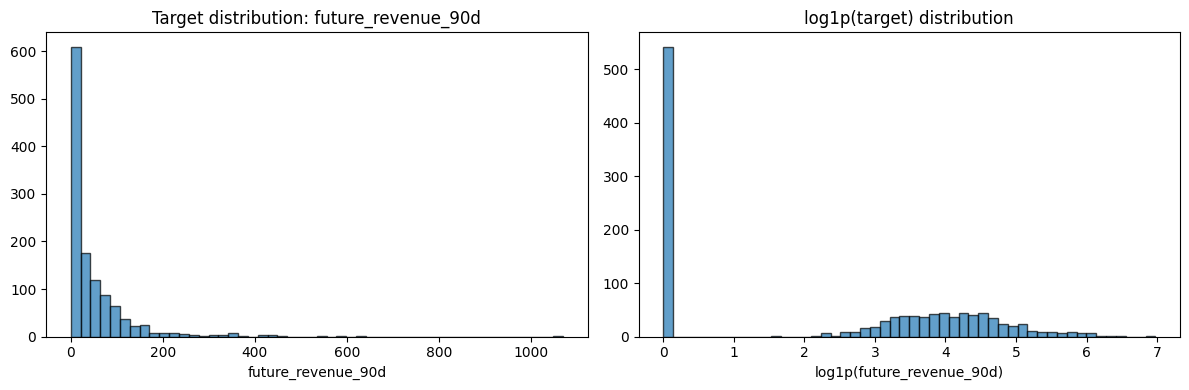

Target is right-skewed (common for revenue). log1p transform can be considered in downstream modeling.


In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(final_dataset["future_revenue_90d"], bins=50, edgecolor="black", alpha=0.7)
axes[0].set_title("Target distribution: future_revenue_90d")
axes[0].set_xlabel("future_revenue_90d")

axes[1].hist(np.log1p(final_dataset["future_revenue_90d"]), bins=50, edgecolor="black", alpha=0.7)
axes[1].set_title("log1p(target) distribution")
axes[1].set_xlabel("log1p(future_revenue_90d)")

plt.tight_layout()
plt.show()

print("Target is right-skewed (common for revenue). log1p transform can be considered in downstream modeling.")